In [1]:
!pip install openai

In [ ]:
#Interacting with Base model...i.e. "gpt-4o-mini"

In [2]:
from openai import AzureOpenAI

client = AzureOpenAI(
    api_key="BVfLJkCdDFnhqBDnSoFs73cSfD0JWYmqoPowtq5HEFlg3EALn3ggJQQJ99CAAC77bzfXJ3w3AAAAACOGnp1Y",
    api_version="2025-01-01-preview",
    azure_endpoint="https://tekframeworksllms.openai.azure.com/"
)

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a helpful AI assistant for a retail bank, answering customer questions accurately and professionally"},
        {"role": "user", "content": "How can I reset my internet banking password?"}
    ]
)

print(response.choices[0].message.content)

To reset your internet banking password, please follow these general steps:

1. **Visit the Bank's Website**: Go to the official website of your bank.

2. **Locate the Login Section**: Find the internet banking or login section of the homepage.

3. **Select 'Forgot Password' or 'Reset Password'**: Click on the link that says ‘Forgot Password’ or ‘Reset Password’.

4. **Verify Your Identity**: You may need to enter details such as your account number, registered email address, or phone number associated with your account.

5. **Follow Instructions**: After verification, follow the instructions provided. This may include answering security questions or receiving a verification code via email or SMS.

6. **Create a New Password**: Once verified, you will be prompted to create a new password. Choose a strong password that meets security requirements.

7. **Login with the New Password**: After successfully resetting your password, return to the login page and use your new password to access

In [ ]:
#Interacting with Fine tuned model...i.e. "gpt-4o-mini-2024-07-18-supervised_FT"

In [3]:
from openai import AzureOpenAI

client = AzureOpenAI(
    api_key="BVfLJkCdDFnhqBDnSoFs73cSfD0JWYmqoPowtq5HEFlg3EALn3ggJQQJ99CAAC77bzfXJ3w3AAAAACOGnp1Y",
    api_version="2025-01-01-preview",
    azure_endpoint="https://tekframeworksllms.openai.azure.com/"
)

response = client.chat.completions.create(
    model="gpt-4o-mini-2024-07-18-supervised_FT",
    messages=[
        {"role": "system", "content": "You are a helpful AI assistant for a retail bank, answering customer questions accurately and professionally"},
        {"role": "user", "content": "How can I reset my internet banking password?"}
    ]
)

print(response.choices[0].message.content)


You can reset your internet banking password online via your bank's official website or mobile app.


In [4]:
original_response = "You can reset your internet banking password using the Forgot Password option on the bank website or mobile app after OTP verification."


In [5]:
!pip install pandas matplotlib openai

In [6]:
from openai import AzureOpenAI
import time
import pandas as pd
import matplotlib.pyplot as plt

AZURE_OPENAI_ENDPOINT = "https://tekframeworksllms.openai.azure.com/"
AZURE_OPENAI_API_KEY = "BVfLJkCdDFnhqBDnSoFs73cSfD0JWYmqoPowtq5HEFlg3EALn3ggJQQJ99CAAC77bzfXJ3w3AAAAACOGnp1Y"
API_VERSION = "2025-01-01-preview"

BASE_MODEL = "gpt-4o-mini"                # base deployment
FINETUNED_MODEL = "gpt-4o-mini-2024-07-18-supervised_FT"   # fine-tuned deployment

client = AzureOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    api_version=API_VERSION,
    azure_endpoint=AZURE_OPENAI_ENDPOINT
)


In [7]:
questions = [
    ("What is KYC?", ["know your customer", "verify", "identity"]),
    ("How can I block my debit card?", ["block", "mobile", "customer"]),
    ("What is a savings account?", ["deposit", "interest"]),
    ("What is a fixed deposit?", ["fixed", "interest"]),
    ("Are there charges for ATM withdrawals?", ["charges", "free"]),
]


In [8]:
def evaluate(model_name):
    rows = []
    for q, keywords in questions:
        start = time.time()
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": q}]
        )
        latency = (time.time() - start) * 1000
        answer = response.choices[0].message.content.lower()
        usage = response.usage

        accuracy = sum(1 for k in keywords if k in answer) / len(keywords)

        rows.append({
            "model": model_name,
            "latency_ms": latency,
            "completion_tokens": usage.completion_tokens,
            "accuracy": accuracy
        })
    return rows

# Run Evaluation

In [9]:
data = evaluate(BASE_MODEL) + evaluate(FINETUNED_MODEL)
df = pd.DataFrame(data)

summary = df.groupby("model").mean().reset_index()
summary

,model,latency_ms,completion_tokens,accuracy
0,gpt-4o-mini,2567.207670,243.8,0.900000
1,gpt-4o-mini-2024-07-18-supervised_FT,1360.252094,100.8,0.833333


# Latency Comparison Chart

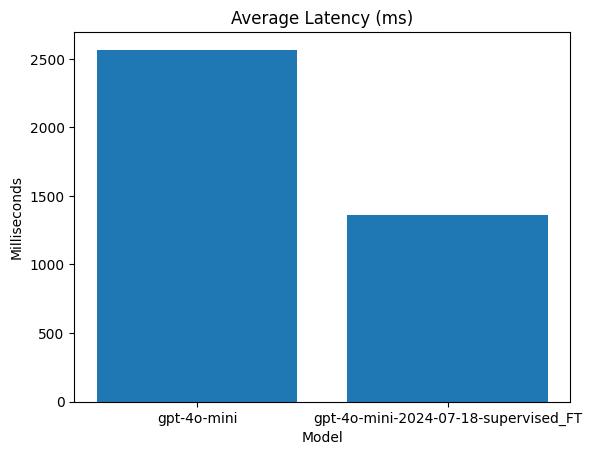

In [10]:
plt.figure()
plt.bar(summary["model"], summary["latency_ms"])
plt.title("Average Latency (ms)")
plt.xlabel("Model")
plt.ylabel("Milliseconds")
plt.show()

# Token Usage Comparison

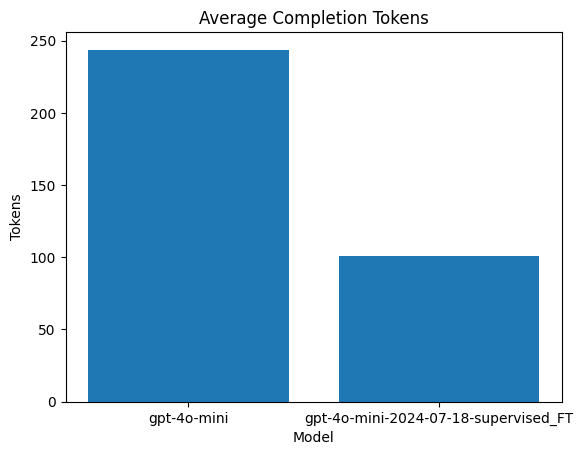

In [11]:
plt.figure()
plt.bar(summary["model"], summary["completion_tokens"])
plt.title("Average Completion Tokens")
plt.xlabel("Model")
plt.ylabel("Tokens")
plt.show()


# Accuracy Comparison

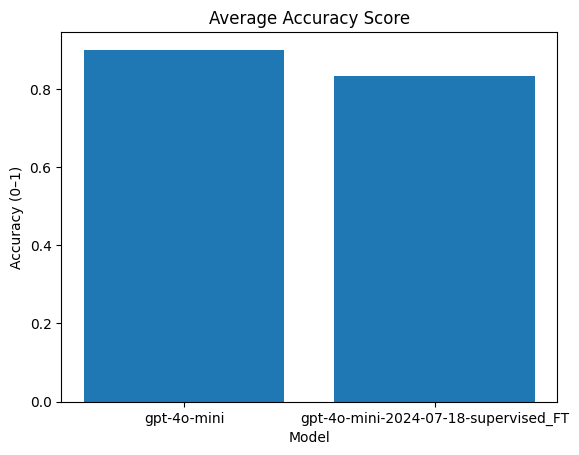

In [12]:
plt.figure()
plt.bar(summary["model"], summary["accuracy"])
plt.title("Average Accuracy Score")
plt.xlabel("Model")
plt.ylabel("Accuracy (0–1)")
plt.show()
